# Trening Modelu Ekojazdy dla ESP32 (Random Forest)

Ten notatnik przeprowadza cały proces od surowych danych z magistrali CAN do gotowego pliku nagłówkowego w języku C (`eco_model.h`).

## Krok 1: Wczytanie bibliotek i Inżynieria Cech (Feature Engineering)
Przekształcamy surowe ramki CAN na dane oddające dynamikę pojazdu. Wyliczamy:
* $\Delta t$ (różnica czasu w sekundach)
* Przyspieszenie ($m/s^2$) i Szarpnięcie ($m/s^3$)
* Chwilowe spalanie (na podstawie wariacji całkowitego zużycia paliwa)
* Odchylenie standardowe wciskania gazu (wykrywanie tzw. "nerwowej nogi")

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import emlearn

# Ustawienia ładnego wyglądu wykresów
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# 1. Wczytanie surowego pliku CSV z karty SD
# Upewnij się, że plik leży w tym samym folderze co notatnik
df = pd.read_csv('data/20260410_131901.csv')
# df = pd.read_csv('data/20260410_125556.csv')
# df = pd.read_csv('data/20260406_095734.csv')

# 2. Inżynieria cech (Feature Engineering)
# Różnica czasu w sekundach (timestamp z ESP jest w ms)
df['dt'] = df['timestamp'].diff() / 1000.0

# Usunięcie pierwszego wiersza (gdzie dt to NaN)
df = df.dropna()
df = df[df['dt'] > 0]

# Podstawowa fizyka: Prędkość [m/s], Przyspieszenie [m/s^2], Szarpnięcie [m/s^3]
df['speed_ms'] = df['speed'] / 3.6
df['acceleration'] = df['speed_ms'].diff() / df['dt']
df['jerk'] = df['acceleration'].diff() / df['dt']

# Chwilowe zużycie paliwa (zmiana całkowitego zużycia na sekundę)
df['delta_fuel'] = df['fuel_cons'].diff()
df['fuel_per_sec'] = df['delta_fuel'] / df['dt']

# Filtrowanie szumu z CAN za pomocą przesuwnych okien czasowych (Rolling Windows)
# Zakładamy okno ok. 2 sekund (20 próbek przy 10Hz)
window_size = 20

# Wariancja gazu z ostatnich 2 sekund - kluczowy parametr dla algorytmu!
df['throttle_std'] = df['throttle'].rolling(window=window_size).std()

# Średnie wciśnięcie hamulca i maksymalne szarpnięcie z ostatnich 2 sekund
df['brake_mean'] = df['brake'].rolling(window=window_size).mean()
df['jerk_max'] = df['jerk'].abs().rolling(window=window_size).max()

# Usunięcie pustych wierszy powstałych na skutek "rozbiegówki" okien przesuwnych
df = df.dropna().copy()
df = df.reset_index(drop=True)

print(f"Inżynieria cech zakończona sukcesem! Załadowano i przetworzono {len(df)} próbek.")

Inżynieria cech zakończona sukcesem! Załadowano i przetworzono 4766 próbek.


## Krok 2: Automatyczne Etykietowanie (Rule-based Labeling)
Ponieważ nie oznaczaliśmy stylu jazdy ręcznie w trakcie prowadzenia auta, musimy użyć **heurystyki**. 

Zbudujemy algorytm fizyczny obliczający wskaźnik **Kosztu Energetycznego**. Im wyższy koszt, tym bardziej marnujemy energię.
* `alpha`: Waga za spalanie chwilowe.
* `beta`: Waga za użycie hamulca (bezpowrotna strata energii). *Uwaga: wartość zredukowana do 0.05 ze względu na brak normalizacji (zakres hamulca to 0-1023).*
* `gamma`: Waga za szarpanie (częste zmiany przyspieszenia).

In [2]:
# Wagi algorytmu oceniającego - możesz je swobodnie modyfikować i uruchamiać tę komórkę ponownie
alpha = 1.0    # Zużycie paliwa
beta = 0.05    # Hamowanie (waga niska, by zrównoważyć zakres 0-1023 surowych danych)
gamma = 0.2    # Szarpnięcie

# Wyliczenie indeksu kosztu dla każdej próbki czasu
df['energy_cost'] = (alpha * df['fuel_per_sec']) + (beta * df['brake_mean']) + (gamma * df['jerk_max'])

# Sortowanie i podział na 3 klasy na podstawie kwantyli całego przejazdu
q_eco = df['energy_cost'].quantile(0.25) # 25% najlepszych momentów to EKO
q_agg = df['energy_cost'].quantile(0.95) # 5% najgorszych momentów to AGRESJA

def assign_label(cost):
    if cost <= q_eco:
        return 2  # Klasa 2: Eko
    elif cost >= q_agg:
        return 0  # Klasa 0: Agresywna
    else:
        return 1  # Klasa 1: Normalna

df['label'] = df['energy_cost'].apply(assign_label)
print("Etykiety wyznaczone. Możesz przejść do wizualizacji.")

Etykiety wyznaczone. Możesz przejść do wizualizacji.


## Krok 3: Weryfikacja Wizualna (Wykres Profilu Jazdy)
Zanim wytrenujemy model ML, musimy jako inżynierowie upewnić się, że nasza heurystyka działa z sensem.
Poniższy wykres nałoży na siebie **Prędkość**, użycie **Gazu** oraz tło reprezentujące ocenę:
* **Zielone tło:** Jazda sklasyfikowana jako EKO.
* **Czerwone tło:** Jazda sklasyfikowana jako Agresywna/Nieekonomiczna.
* **Brak tła:** Jazda Normalna.

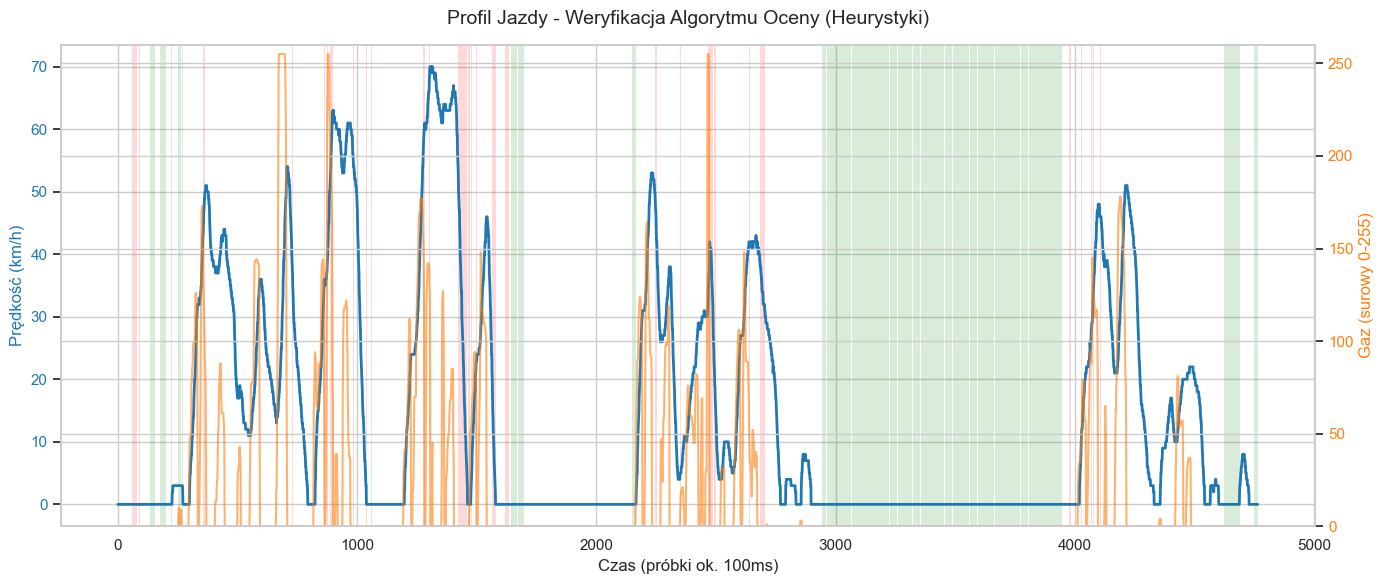

In [3]:
# Ograniczamy wykres do wybranych próbek, żeby był czytelny. 
# Zmień np. df.head(1000) na df.iloc[200:800], aby obejrzeć inny fragment trasy.
df_plot = df.iloc[0:10000].reset_index(drop=True)

fig, ax1 = plt.subplots()

# Rysowanie Prędkości na lewej osi Y
color_speed = '#1f77b4'
ax1.set_xlabel('Czas (próbki ok. 100ms)')
ax1.set_ylabel('Prędkość (km/h)', color=color_speed)
ax1.plot(df_plot.index, df_plot['speed'], color=color_speed, linewidth=2, label='Prędkość')
ax1.tick_params(axis='y', labelcolor=color_speed)

# Rysowanie Gazu na prawej osi Y
ax2 = ax1.twinx()  
color_throttle = '#ff7f0e'
ax2.set_ylabel('Gaz (surowy 0-255)', color=color_throttle)  
ax2.plot(df_plot.index, df_plot['throttle'], color=color_throttle, alpha=0.6, linewidth=1.5, label='Gaz')
ax2.tick_params(axis='y', labelcolor=color_throttle)
ax2.set_ylim(0, 260) # Stały zakres dla lepszej widoczności

# Rysowanie Tła w zależności od nadanej etykiety
for i in range(len(df_plot) - 1):
    lbl = df_plot.loc[i, 'label']
    if lbl == 2:   # Eko
        ax1.axvspan(i, i+1, color='green', alpha=0.15, lw=0)
    elif lbl == 0: # Agresja
        ax1.axvspan(i, i+1, color='red', alpha=0.15, lw=0)

plt.title('Profil Jazdy - Weryfikacja Algorytmu Oceny (Heurystyki)', fontsize=14, pad=15)
fig.tight_layout()  
plt.show()

## Krok 4: Trening Modelu ML i Eksport (TinyML)
Teraz trenujemy model ML typu **Random Forest**. Jako dane wejściowe przekazujemy mu tylko te zmienne, które ESP32 jest w stanie bez problemu podać lub policzyć w czasie rzeczywistym.

Na końcu model zostaje przetłumaczony na czysty język C i zapisany jako `eco_model.h`.

In [4]:
# Zdefiniowanie cech (Features), które będą wchodziły do modelu na mikrokontrolerze
features_for_model = ['speed', 'rpm', 'throttle', 'brake', 'acceleration', 'throttle_std']

X = df[features_for_model].values
y = df['label'].values

# Podział na zbiór treningowy (80%) i testowy (20%) dla walidacji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Konfiguracja modelu Random Forest
# n_estimators = 25 (ilość drzew decyzyjnych - kompromis między skutecznością a rozmiarem kodu C)
# max_depth = 12 (maksymalna głębokość zapobiega przeuczeniu)
clf = RandomForestClassifier(n_estimators=25, max_depth=12, random_state=42)

# Trenowanie modelu
print("Trwa trenowanie modelu Lasu Losowego...")
clf.fit(X_train, y_train)

# Sprawdzenie skuteczności
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Ogólna Skuteczność (Accuracy) na danych testowych: {accuracy:.2f}%\n")

print("Szczegółowy Raport Klasyfikacji:")
print(classification_report(y_test, y_pred, target_names=['Agresywna (0)', 'Normalna (1)', 'Eko (2)']))

# ---------------------------------------------------------
# Magia TinyML: Tłumaczenie modelu do czystego C
# ---------------------------------------------------------
print("Generowanie pliku nagłówkowego w czystym C dla ESP32...")
try:
    # Konwersja do czystego C (metoda 'inline' wrzuca wszystko jako płaskie instrukcje if-else)
    cmodel = emlearn.convert(clf, method='inline')
    
    # Zapis generuje plik eco_model.h. 
    # Argument 'name' to prefiks, jaki będą miały funkcje w C.
    cmodel.save(file='eco_model.h', name='eco_model')
        
    print("\n✅ SUKCES! Plik eco_model.h w standardzie C został wygenerowany.")
except Exception as e:
    print(f"\n❌ Błąd podczas generowania kodu C: {e}")

Trwa trenowanie modelu Lasu Losowego...
Ogólna Skuteczność (Accuracy) na danych testowych: 92.35%

Szczegółowy Raport Klasyfikacji:
               precision    recall  f1-score   support

Agresywna (0)       0.71      0.47      0.56        51
 Normalna (1)       0.93      0.96      0.95       651
      Eko (2)       0.92      0.92      0.92       252

     accuracy                           0.92       954
    macro avg       0.85      0.78      0.81       954
 weighted avg       0.92      0.92      0.92       954

Generowanie pliku nagłówkowego w czystym C dla ESP32...

✅ SUKCES! Plik eco_model.h w standardzie C został wygenerowany.
